# 1.How do the top and bottom 10 NBA teams compare statistically using assists, turnovers, rebounds, free throw attempts, and steals over the years between 2010-2024?

# 2. Are there any specific statistical factors that strongly correlate with total wins in the NBA from 2010-2024?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#read in data
regular_season_totals = pd.read_csv('../NBA_Player_Evolution_2020-2024/regular_season_totals_2010_2024.csv')
regular_season_totals1 = pd.read_csv('../NBA_Player_Evolution_2020-2024/regular_season_totals_2010_2024.csv')
#Change season_year and game_date to date-time format
regular_season_totals['GAME_DATE'] = pd.to_datetime(regular_season_totals['GAME_DATE'])

regular_season_totals['SEASON_YEAR'].unique()

#filter for wins
Wins = regular_season_totals[regular_season_totals['WL']=='W']

regular_season_totals6 = Wins.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

team_yearly_avg = regular_season_totals.groupby(['TEAM_NAME', 'SEASON_YEAR']).agg({
    'AST': 'mean',
    'REB': 'mean',
    'TOV': 'mean',
    'FTA': 'mean',
    'STL': 'mean'
}).reset_index()



team_summary = team_yearly_avg.merge(Wins, on=['TEAM_NAME', 'SEASON_YEAR'], how='left')

In [4]:
Wins = regular_season_totals[regular_season_totals['WL'] == 'W'].groupby(['TEAM_NAME', 'SEASON_YEAR']).size().reset_index(name='Total_Wins')
team_summary = team_yearly_avg.merge(Wins, on=['TEAM_NAME', 'SEASON_YEAR'], how='left')


In [5]:
#Finding the correlation

numeric_summary = team_summary.select_dtypes(include='number')
possible_correlation = numeric_summary.corr()
possible_correlation
possible_correlation.to_csv('possible_correlation.csv', index=True)

possible_correlation
numeric_summary
numeric_summary.to_csv('numeric_summary.csv', index=False)
possible_correlation

,AST,REB,TOV,FTA,STL,Total_Wins
AST,1.000000,0.273569,-0.068821,-0.234509,0.101359,0.263327
REB,0.273569,1.000000,0.048725,0.142616,-0.141545,0.247540
TOV,-0.068821,0.048725,1.000000,0.224893,0.153580,-0.303020
FTA,-0.234509,0.142616,0.224893,1.000000,0.066196,0.117549
STL,0.101359,-0.141545,0.153580,0.066196,1.000000,0.166787
Total_Wins,0.263327,0.247540,-0.303020,0.117549,0.166787,1.000000


Text(0.5, 1.0, 'Correlation Graph')

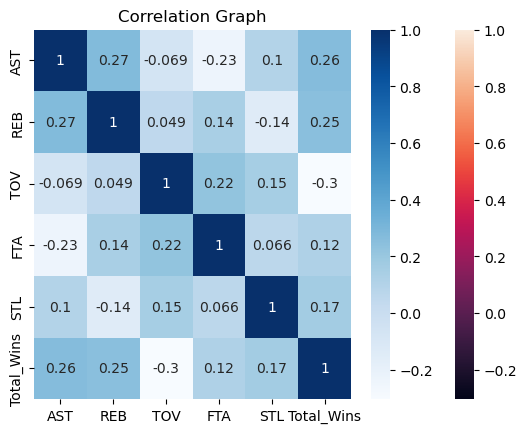

In [6]:
sns.heatmap(possible_correlation)
sns.heatmap(possible_correlation, cmap="Blues", annot=True)
plt.title('Correlation Graph')

In [7]:

plt.savefig('sns.Correlation Graph.png')

<Figure size 640x480 with 0 Axes>

In [8]:
#Filter necessary rows
regular_season_totals = regular_season_totals[['SEASON_YEAR', 'GAME_DATE', 'GAME_ID', 'TEAM_ID', 'TEAM_NAME', 'WL', 'FG3A', 'FG3_PCT', 'FG_PCT', 'FTA', 'FT_PCT', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']]

regular_season_totals_new = regular_season_totals[['Total_Wins', 'TEAM_AST', 'TEAM_REB', 'TEAM_STL', 'TEAM_TOV', 'TEAM_FTA', 'TEAM_FT_PCT']]

In [10]:
#Filter year over year
year_2010_11 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2010-11']

#Find the team yearly averages
team_2010_11_avg_pct = year_2010_11.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

team_2010_11_avg_fta = year_2010_11.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2010_11_ft_pct = year_2010_11.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2010_11_avg_rb = year_2010_11.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2010_11_avg_ast = year_2010_11.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2010_11_avg_tov = year_2010_11.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2010_11_avg_stl = year_2010_11.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2010_11_avg_plmin = year_2010_11.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the average 3 points attempted by team
team_2010_11_avg_fga = year_2010_11.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

#Find the years average FG3A 
year_2010_11_avg_fga = year_2010_11['FG3A'].mean()

#Find the years average
year_2010_11_avg_3perc = year_2010_11['FG3_PCT'].mean()

year_2010_11_avg_fta = year_2010_11['FTA'].mean()

year_2010_11_avg_ft_pct = year_2010_11['FT_PCT'].mean()

year_2010_11_avg_rb = year_2010_11['REB'].mean()

year_2010_11_avg_ast = year_2010_11['AST'].mean()

year_2010_11_avg_tov = year_2010_11['TOV'].mean()

year_2010_11_avg_stl = year_2010_11['STL'].mean()

year_2010_11_avg_plmin = year_2010_11['PLUS_MINUS'].mean()

#Filter the DF to just show wins
wins_2010_11 = year_2010_11[year_2010_11['WL'] == 'W']

#Find the teams overall wins
year_2010_11_total_wins = wins_2010_11.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [11]:
#Create table

team_2010_11_avg_pct['TEAM FG3A']= team_2010_11_avg_fga['FG3A']
team_2010_11_avg_pct['TEAM FTA'] = team_2010_11_avg_fta['FTA'] 
team_2010_11_avg_pct['TEAM FT_PCT'] = team_2010_11_ft_pct['FT_PCT'] 
team_2010_11_avg_pct['TEAM REB'] = team_2010_11_avg_rb['REB'] 
team_2010_11_avg_pct['TEAM AST'] = team_2010_11_avg_ast['AST']
team_2010_11_avg_pct['TEAM TOV'] = team_2010_11_avg_tov['TOV'] 
team_2010_11_avg_pct['TEAM STL'] = team_2010_11_avg_stl['STL'] 
team_2010_11_avg_pct['TEAM PLUS_MINUS'] = team_2010_11_avg_plmin['PLUS_MINUS'] 
team_2010_11_avg_pct['TEAM Total_Wins']= year_2010_11_total_wins['Total_Wins']
team_2010_11_avg_pct

,TEAM_NAME,FG3_PCT,TEAM FG3A,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS,TEAM Total_Wins
0,Atlanta Hawks,0.359488,17.402439,21.073171,0.773268,39.292683,21.975610,13.634146,6.060976,-0.817073,44
1,Boston Celtics,0.361451,13.646341,23.109756,0.767768,38.792683,23.426829,14.573171,8.243902,5.365854,56
2,Charlotte Bobcats,0.319585,14.670732,24.378049,0.755293,40.146341,21.073171,14.536585,6.390244,-4.000000,34
3,Chicago Bulls,0.360329,17.256098,24.487805,0.742012,44.158537,22.280488,14.158537,7.219512,7.317073,62
4,Cleveland Cavaliers,0.341341,18.158537,25.304878,0.743220,40.304878,20.975610,14.219512,6.634146,-9.012195,19
5,Dallas Mavericks,0.364427,21.560976,22.560976,0.775000,41.439024,23.829268,13.963415,6.792683,4.231707,57
6,Denver Nuggets,0.379817,20.780488,29.621951,0.765817,41.987805,22.109756,14.109756,7.378049,4.756098,50
7,Detroit Pistons,0.370073,15.317073,22.609756,0.740927,38.621951,21.097561,13.012195,7.256098,-3.597561,30
8,Golden State Warriors,0.384293,21.329268,20.670732,0.754890,40.548780,22.524390,14.609756,8.987805,-2.329268,36
9,Houston Rockets,0.366317,22.475610,25.402439,0.802268,42.817073,23.841463,13.536585,7.085366,2.182927,43


In [12]:
#finished dataframe for 2010-2011
team_2010_11_avg_pct

,TEAM_NAME,FG3_PCT,TEAM FG3A,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS,TEAM Total_Wins
0,Atlanta Hawks,0.359488,17.402439,21.073171,0.773268,39.292683,21.975610,13.634146,6.060976,-0.817073,44
1,Boston Celtics,0.361451,13.646341,23.109756,0.767768,38.792683,23.426829,14.573171,8.243902,5.365854,56
2,Charlotte Bobcats,0.319585,14.670732,24.378049,0.755293,40.146341,21.073171,14.536585,6.390244,-4.000000,34
3,Chicago Bulls,0.360329,17.256098,24.487805,0.742012,44.158537,22.280488,14.158537,7.219512,7.317073,62
4,Cleveland Cavaliers,0.341341,18.158537,25.304878,0.743220,40.304878,20.975610,14.219512,6.634146,-9.012195,19
5,Dallas Mavericks,0.364427,21.560976,22.560976,0.775000,41.439024,23.829268,13.963415,6.792683,4.231707,57
6,Denver Nuggets,0.379817,20.780488,29.621951,0.765817,41.987805,22.109756,14.109756,7.378049,4.756098,50
7,Detroit Pistons,0.370073,15.317073,22.609756,0.740927,38.621951,21.097561,13.012195,7.256098,-3.597561,30
8,Golden State Warriors,0.384293,21.329268,20.670732,0.754890,40.548780,22.524390,14.609756,8.987805,-2.329268,36
9,Houston Rockets,0.366317,22.475610,25.402439,0.802268,42.817073,23.841463,13.536585,7.085366,2.182927,43


In [13]:
#Filter year over year
year_2011_12 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2011-12']

#Find the overall 3p% per team for this year
team_2011_12_avg_pct = year_2011_12.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2011_12_avg_fga = year_2011_12.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2011_12_avg_fta = year_2011_12.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2011_12_ft_pct = year_2011_12.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2011_12_avg_rb = year_2011_12.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2011_12_avg_ast = year_2011_12.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2011_12_avg_tov = year_2011_12.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2011_12_avg_stl = year_2011_12.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2011_12_avg_plmin = year_2011_12.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2011_12_avg_fga = year_2011_12['FG3A'].mean()

#Find the years average FG3%
year_2011_12_avg_3perc = year_2011_12['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2011_12 = year_2011_12[year_2011_12['WL'] == 'W']

#Find the teams overall wins
year_2011_12_total_wins = wins_2011_12.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [14]:
#Create table

team_2011_12_avg_pct['FG3A']= team_2011_12_avg_fga['FG3A']
team_2011_12_avg_pct['SEASON_YEAR'] = '2011-2012'
team_2011_12_avg_pct['Total_Wins']= year_2011_12_total_wins['Total_Wins']
team_2011_12_avg_pct['TEAM FTA'] = team_2011_12_avg_fta['FTA'] 
team_2011_12_avg_pct['TEAM FT_PCT'] = team_2011_12_ft_pct['FT_PCT'] 
team_2011_12_avg_pct['TEAM REB'] = team_2011_12_avg_rb['REB'] 
team_2011_12_avg_pct['TEAM AST'] = team_2011_12_avg_ast['AST']
team_2011_12_avg_pct['TEAM TOV'] = team_2011_12_avg_tov['TOV'] 
team_2011_12_avg_pct['TEAM STL'] = team_2011_12_avg_stl['STL'] 
team_2011_12_avg_pct['TEAM PLUS_MINUS'] = team_2011_12_avg_plmin['PLUS_MINUS']
team_2011_12_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.371727,20.151515,2011-2012,40,20.984848,0.748636,41.181818,22.439394,13.954545,8.121212,3.439394
1,Boston Celtics,0.361061,14.969697,2011-2012,39,19.818182,0.785864,38.787879,23.590909,14.833333,7.545455,2.515152
2,Charlotte Bobcats,0.287742,13.515152,2011-2012,7,22.151515,0.742758,38.954545,20.090909,14.500000,6.015152,-13.909091
3,Chicago Bulls,0.375848,16.924242,2011-2012,50,21.121212,0.719500,46.666667,23.136364,13.984848,6.909091,8.181818
4,Cleveland Cavaliers,0.343970,19.287879,2011-2012,21,24.924242,0.719076,42.272727,19.818182,15.409091,7.060606,-7.196970
5,Dallas Mavericks,0.340591,22.181818,2011-2012,36,20.212121,0.771303,42.757576,20.909091,14.030303,8.560606,0.954545
6,Denver Nuggets,0.334818,19.863636,2011-2012,38,26.666667,0.736030,43.075758,23.954545,15.378788,8.181818,2.878788
7,Detroit Pistons,0.334697,13.878788,2011-2012,25,22.136364,0.759288,40.257576,18.666667,15.651515,6.969697,-4.787879
8,Golden State Warriors,0.379848,20.469697,2011-2012,23,18.712121,0.769742,39.196970,22.272727,13.863636,8.000000,-3.409091
9,Houston Rockets,0.361000,20.151515,2011-2012,34,19.712121,0.779788,42.166667,21.272727,14.469697,7.515152,0.227273


In [15]:
#Filter year over year
year_2012_13 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2012-13']

#Find the overall 3p% per team for this year
team_2012_13_avg_pct = year_2012_13.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2012_13_avg_fga = year_2012_13.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2012_13_avg_fta = year_2012_13.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2012_13_ft_pct = year_2012_13.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2012_13_avg_rb = year_2012_13.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2012_13_avg_ast = year_2012_13.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2012_13_avg_tov = year_2012_13.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2012_13_avg_stl = year_2012_13.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2012_13_avg_plmin = year_2012_13.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2012_13_avg_fga = year_2012_13['FG3A'].mean()

#Find the years average FG3%
year_2012_13_avg_3perc = year_2012_13['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2012_13 = year_2012_13[year_2012_13['WL'] == 'W']

#Find the teams overall wins
year_2012_13_total_wins = wins_2012_13.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')



In [16]:
#Create table

team_2012_13_avg_pct['FG3A']= team_2012_13_avg_fga['FG3A']
team_2012_13_avg_pct['SEASON_YEAR'] = '2012-2013'
team_2012_13_avg_pct['Total_Wins']= year_2012_13_total_wins['Total_Wins']
team_2012_13_avg_pct['TEAM FTA'] = team_2012_13_avg_fta['FTA'] 
team_2012_13_avg_pct['TEAM FT_PCT'] = team_2012_13_ft_pct['FT_PCT'] 
team_2012_13_avg_pct['TEAM REB'] = team_2012_13_avg_rb['REB'] 
team_2012_13_avg_pct['TEAM AST'] = team_2012_13_avg_ast['AST']
team_2012_13_avg_pct['TEAM TOV'] = team_2012_13_avg_tov['TOV'] 
team_2012_13_avg_pct['TEAM STL'] = team_2012_13_avg_stl['STL'] 
team_2012_13_avg_pct['TEAM PLUS_MINUS'] = team_2012_13_avg_plmin['PLUS_MINUS']
team_2012_13_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.373317,23.182927,2012-2013,44,19.743902,0.708512,40.865854,24.475610,14.865854,8.097561,0.402439
1,Boston Celtics,0.360049,17.160494,2012-2013,41,20.962963,0.776481,39.345679,22.753086,14.580247,8.234568,-0.222222
2,Brooklyn Nets,0.356366,21.463415,2012-2013,49,23.878049,0.732146,42.768293,20.341463,14.707317,7.304878,1.780488
3,Charlotte Bobcats,0.333854,17.060976,2012-2013,21,25.121951,0.753902,40.317073,19.353659,14.060976,7.207317,-9.231707
4,Chicago Bulls,0.350817,15.426829,2012-2013,45,21.195122,0.774329,43.170732,23.000000,14.280488,7.170732,0.317073
5,Cleveland Cavaliers,0.344024,19.280488,2012-2013,24,22.268293,0.755354,41.012195,20.658537,14.012195,7.890244,-4.682927
6,Dallas Mavericks,0.366098,19.853659,2012-2013,41,20.353659,0.791963,41.914634,23.243902,13.951220,7.902439,-0.597561
7,Denver Nuggets,0.342122,18.512195,2012-2013,57,26.195122,0.699024,45.036585,24.414634,15.280488,9.292683,5.085366
8,Detroit Pistons,0.353427,17.560976,2012-2013,29,22.804878,0.701573,42.121951,21.243902,15.134146,7.000000,-3.987805
9,Golden State Warriors,0.400110,19.902439,2012-2013,47,21.268293,0.792634,44.951220,22.500000,15.073171,6.914634,0.890244


In [17]:
#Filter year over year
year_2013_14 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2013-14']

#Find the overall 3p% per team for this year
team_2013_14_avg_pct = year_2013_14.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2013_14_avg_fga = year_2013_14.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2013_14_avg_fta = year_2013_14.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2013_14_ft_pct = year_2013_14.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2013_14_avg_rb = year_2013_14.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2013_14_avg_ast = year_2013_14.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2013_14_avg_tov = year_2013_14.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2013_14_avg_stl = year_2013_14.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2013_14_avg_plmin = year_2013_14.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2013_14_avg_fga = year_2013_14['FG3A'].mean()

#Find the years average FG3%
year_2013_14_avg_3perc = year_2013_14['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2013_14 = year_2013_14[year_2013_14['WL'] == 'W']

#Find the teams overall wins
year_2013_14_total_wins = wins_2013_14.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')


In [18]:
#Create table

team_2013_14_avg_pct['FG3A']= team_2013_14_avg_fga['FG3A']
team_2013_14_avg_pct['SEASON_YEAR'] = '2013-2014'
team_2013_14_avg_pct['Total_Wins']= year_2013_14_total_wins['Total_Wins']
team_2013_14_avg_pct['TEAM FTA'] = team_2013_14_avg_fta['FTA'] 
team_2013_14_avg_pct['TEAM FT_PCT'] = team_2013_14_ft_pct['FT_PCT'] 
team_2013_14_avg_pct['TEAM REB'] = team_2013_14_avg_rb['REB'] 
team_2013_14_avg_pct['TEAM AST'] = team_2013_14_avg_ast['AST']
team_2013_14_avg_pct['TEAM TOV'] = team_2013_14_avg_tov['TOV'] 
team_2013_14_avg_pct['TEAM STL'] = team_2013_14_avg_stl['STL'] 
team_2013_14_avg_pct['TEAM PLUS_MINUS'] = team_2013_14_avg_plmin['PLUS_MINUS']
team_2013_14_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.359793,25.804878,2013-2014,38,21.731707,0.782963,39.975610,24.890244,15.256098,8.292683,-0.475610
1,Boston Celtics,0.327171,21.085366,2013-2014,25,20.804878,0.785415,42.500000,21.048780,15.378049,7.121951,-4.463415
2,Brooklyn Nets,0.361634,23.439024,2013-2014,44,24.414634,0.754402,38.146341,20.902439,14.524390,8.597561,-1.000000
3,Charlotte Bobcats,0.349585,17.939024,2013-2014,43,24.390244,0.738854,42.682927,21.682927,12.317073,6.085366,-0.219512
4,Chicago Bulls,0.346598,17.792683,2013-2014,48,23.268293,0.781122,44.146341,22.682927,14.914634,7.243902,1.853659
5,Cleveland Cavaliers,0.354768,20.000000,2013-2014,33,22.695122,0.749500,44.121951,21.195122,14.182927,7.060976,-3.292683
6,Dallas Mavericks,0.381805,22.890244,2013-2014,49,21.134146,0.788829,40.902439,23.597561,13.536585,8.585366,2.402439
7,Denver Nuggets,0.357195,23.890244,2013-2014,36,26.268293,0.727110,45.439024,22.414634,15.914634,7.500000,-2.146341
8,Detroit Pistons,0.312463,19.268293,2013-2014,29,25.743902,0.668634,45.378049,20.902439,14.548780,8.378049,-3.658537
9,Golden State Warriors,0.379049,24.841463,2013-2014,51,21.109756,0.756049,45.304878,23.317073,15.207317,7.829268,4.804878


In [19]:
#Filter year over year
year_2014_15 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2014-15']

#Find the overall 3p% per team for this year
team_2014_15_avg_pct = year_2014_15.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2014_15_avg_fga = year_2014_15.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2014_15_avg_fta = year_2014_15.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2014_15_ft_pct = year_2014_15.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2014_15_avg_rb = year_2014_15.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2014_15_avg_ast = year_2014_15.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2014_15_avg_tov = year_2014_15.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2014_15_avg_stl = year_2014_15.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2014_15_avg_plmin = year_2014_15.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2014_15_avg_fga = year_2014_15['FG3A'].mean()

#Find the years average FG3%
year_2014_15_avg_3perc = year_2014_15['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2014_15 = year_2014_15[year_2014_15['WL'] == 'W']

#Find the teams overall wins
year_2014_15_total_wins = wins_2014_15.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [20]:
#Create table

team_2014_15_avg_pct['FG3A']= team_2014_15_avg_fga['FG3A']
team_2014_15_avg_pct['SEASON_YEAR'] = '2014-2015'
team_2014_15_avg_pct['Total_Wins']= year_2014_15_total_wins['Total_Wins']
team_2014_15_avg_pct['TEAM FTA'] = team_2014_15_avg_fta['FTA'] 
team_2014_15_avg_pct['TEAM FT_PCT'] = team_2014_15_ft_pct['FT_PCT'] 
team_2014_15_avg_pct['TEAM REB'] = team_2014_15_avg_rb['REB'] 
team_2014_15_avg_pct['TEAM AST'] = team_2014_15_avg_ast['AST']
team_2014_15_avg_pct['TEAM TOV'] = team_2014_15_avg_tov['TOV'] 
team_2014_15_avg_pct['TEAM STL'] = team_2014_15_avg_stl['STL'] 
team_2014_15_avg_pct['TEAM PLUS_MINUS'] = team_2014_15_avg_plmin['PLUS_MINUS']
team_2014_15_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.380146,26.243902,2014-2015,60,21.158537,0.776512,40.560976,25.743902,14.231707,9.073171,5.426829
1,Boston Celtics,0.326183,24.646341,2014-2015,40,20.463415,0.756744,43.841463,24.500000,13.817073,8.219512,0.158537
2,Brooklyn Nets,0.327195,19.914634,2014-2015,38,22.158537,0.748122,42.353659,20.926829,13.817073,7.024390,-2.878049
3,Charlotte Hornets,0.312976,19.097561,2014-2015,33,22.768293,0.747573,44.060976,20.170732,11.902439,6.085366,-3.170732
4,Chicago Bulls,0.353585,22.256098,2014-2015,50,25.207317,0.781890,45.743902,21.719512,13.963415,6.268293,3.000000
5,Cleveland Cavaliers,0.363756,27.475610,2014-2015,53,23.585366,0.745098,42.963415,22.121951,14.280488,7.353659,4.475610
6,Dallas Mavericks,0.349037,25.390244,2014-2015,50,22.475610,0.756354,42.268293,22.512195,12.951220,8.085366,2.902439
7,Denver Nuggets,0.327024,24.780488,2014-2015,30,24.280488,0.732805,44.695122,21.804878,14.219512,7.817073,-3.548780
8,Detroit Pistons,0.339622,24.914634,2014-2015,32,22.414634,0.703195,44.890244,21.597561,13.402439,7.597561,-1.000000
9,Golden State Warriors,0.397878,27.036585,2014-2015,67,20.841463,0.767378,44.719512,27.414634,14.451220,9.292683,10.097561


In [21]:
#Filter year over year
year_2015_16 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2015-16']

#Find the overall 3p% per team for this year
team_2015_16_avg_pct = year_2015_16.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2015_16_avg_fga = year_2015_16.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2015_16_avg_fta = year_2015_16.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2015_16_ft_pct = year_2015_16.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2015_16_avg_rb = year_2015_16.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2015_16_avg_ast = year_2015_16.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2015_16_avg_tov = year_2015_16.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2015_16_avg_stl = year_2015_16.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2015_16_avg_plmin = year_2015_16.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2015_16_avg_fga = year_2015_16['FG3A'].mean()

#Find the years average FG3%
year_2015_16_avg_3perc = year_2015_16['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2015_16 = year_2015_16[year_2015_16['WL'] == 'W']

#Find the teams overall wins
year_2015_16_total_wins = wins_2015_16.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [22]:
#Create table

team_2015_16_avg_pct['FG3A']= team_2015_16_avg_fga['FG3A']
team_2015_16_avg_pct['SEASON_YEAR'] = '2015-2016'
team_2015_16_avg_pct['Total_Wins']= year_2015_16_total_wins['Total_Wins']
team_2015_16_avg_pct['TEAM FTA'] = team_2015_16_avg_fta['FTA'] 
team_2015_16_avg_pct['TEAM FT_PCT'] = team_2015_16_ft_pct['FT_PCT'] 
team_2015_16_avg_pct['TEAM REB'] = team_2015_16_avg_rb['REB'] 
team_2015_16_avg_pct['TEAM AST'] = team_2015_16_avg_ast['AST']
team_2015_16_avg_pct['TEAM TOV'] = team_2015_16_avg_tov['TOV'] 
team_2015_16_avg_pct['TEAM STL'] = team_2015_16_avg_stl['STL'] 
team_2015_16_avg_pct['TEAM PLUS_MINUS'] = team_2015_16_avg_plmin['PLUS_MINUS']
team_2015_16_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.351646,28.365854,2015-2016,48,19.975610,0.778012,42.085366,25.609756,14.951220,9.109756,3.609756
1,Boston Celtics,0.335305,26.121951,2015-2016,48,23.524390,0.788695,44.914634,24.158537,13.743902,9.170732,3.207317
2,Brooklyn Nets,0.348439,18.390244,2015-2016,21,20.719512,0.752134,42.402439,22.304878,14.780488,7.646341,-7.353659
3,Charlotte Hornets,0.361549,29.390244,2015-2016,48,23.670732,0.795195,43.939024,21.682927,12.548780,7.256098,2.719512
4,Chicago Bulls,0.368878,21.378049,2015-2016,42,20.975610,0.782012,46.292683,22.804878,13.914634,6.036585,-1.475610
5,Cleveland Cavaliers,0.362451,29.609756,2015-2016,57,21.743902,0.749146,44.512195,22.695122,13.585366,6.719512,6.000000
6,Dallas Mavericks,0.343012,28.560976,2015-2016,42,22.329268,0.792988,43.073171,22.109756,12.768293,6.829268,-0.304878
7,Denver Nuggets,0.336829,23.695122,2015-2016,33,24.073171,0.769829,44.621951,22.658537,14.658537,7.426829,-3.097561
8,Detroit Pistons,0.343793,26.195122,2015-2016,44,25.548780,0.675171,46.317073,19.439024,13.536585,6.987805,0.609756
9,Golden State Warriors,0.414232,31.609756,2015-2016,73,21.829268,0.767841,46.195122,28.939024,15.182927,8.402439,10.756098


In [23]:
#Filter year over year
year_2016_17 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2016-17']

#Find the overall 3p% per team for this year
team_2016_17_avg_pct = year_2016_17.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2016_17_avg_fga = year_2016_17.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2016_17_avg_fta = year_2016_17.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2016_17_ft_pct = year_2016_17.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2016_17_avg_rb = year_2016_17.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2016_17_avg_ast = year_2016_17.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2016_17_avg_tov = year_2016_17.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2016_17_avg_stl = year_2016_17.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2016_17_avg_plmin = year_2016_17.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2016_17_avg_fga = year_2016_17['FG3A'].mean()

#Find the years average FG3%
year_2016_17_avg_3perc = year_2016_17['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2016_17 = year_2016_17[year_2016_17['WL'] == 'W']

#Find the teams overall wins
year_2016_17_total_wins = wins_2016_17.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [24]:
#Create table

team_2016_17_avg_pct['FG3A']= team_2016_17_avg_fga['FG3A']
team_2016_17_avg_pct['SEASON_YEAR'] = '2016-2017'
team_2016_17_avg_pct['Total_Wins']= year_2016_17_total_wins['Total_Wins']
team_2016_17_avg_pct['TEAM FTA'] = team_2016_17_avg_fta['FTA'] 
team_2016_17_avg_pct['TEAM FT_PCT'] = team_2016_17_ft_pct['FT_PCT'] 
team_2016_17_avg_pct['TEAM REB'] = team_2016_17_avg_rb['REB'] 
team_2016_17_avg_pct['TEAM AST'] = team_2016_17_avg_ast['AST']
team_2016_17_avg_pct['TEAM TOV'] = team_2016_17_avg_tov['TOV'] 
team_2016_17_avg_pct['TEAM STL'] = team_2016_17_avg_stl['STL'] 
team_2016_17_avg_pct['TEAM PLUS_MINUS'] = team_2016_17_avg_plmin['PLUS_MINUS']
team_2016_17_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.341341,26.060976,2016-2017,43,24.865854,0.726061,44.329268,23.634146,15.780488,8.195122,-0.853659
1,Boston Celtics,0.358744,33.426829,2016-2017,53,23.207317,0.810232,41.963415,25.231707,13.268293,7.524390,2.634146
2,Brooklyn Nets,0.337207,31.597561,2016-2017,20,24.634146,0.787280,43.902439,21.414634,16.536585,7.231707,-6.731707
3,Charlotte Hornets,0.348049,28.621951,2016-2017,36,23.817073,0.816476,43.585366,23.060976,11.487805,6.963415,0.195122
4,Chicago Bulls,0.334402,22.329268,2016-2017,41,22.536585,0.797354,46.292683,22.573171,13.560976,7.841463,0.426829
5,Cleveland Cavaliers,0.382171,33.890244,2016-2017,51,23.329268,0.743915,43.743902,22.658537,13.670732,6.573171,3.182927
6,Dallas Mavericks,0.355366,30.158537,2016-2017,33,18.487805,0.797244,38.573171,20.792683,11.853659,7.487805,-2.926829
7,Denver Nuggets,0.368122,28.841463,2016-2017,40,24.219512,0.772341,46.378049,25.329268,14.951220,6.926829,0.512195
8,Detroit Pistons,0.326878,23.353659,2016-2017,37,19.341463,0.722195,45.682927,21.121951,11.865854,7.000000,-1.121951
9,Golden State Warriors,0.385951,31.243902,2016-2017,67,22.560976,0.784232,44.426829,30.378049,14.768293,9.573171,11.634146


In [25]:
#Filter year over year
year_2017_18 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2017-18']

#Find the overall 3p% per team for this year
team_2017_18_avg_pct = year_2017_18.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2017_18_avg_fga = year_2017_18.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2017_18_avg_fta = year_2017_18.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2017_18_ft_pct = year_2017_18.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2017_18_avg_rb = year_2017_18.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2017_18_avg_ast = year_2017_18.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2017_18_avg_tov = year_2017_18.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2017_18_avg_stl = year_2017_18.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2017_18_avg_plmin = year_2017_18.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2017_18_avg_fga = year_2017_18['FG3A'].mean()

#Find the years average FG3%
year_2017_18_avg_3perc = year_2017_18['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2017_18 = year_2017_18[year_2017_18['WL'] == 'W']

#Find the teams overall wins
year_2017_18_total_wins = wins_2017_18.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')


In [26]:
#Create table

team_2017_18_avg_pct['FG3A']= team_2017_18_avg_fga['FG3A']
team_2017_18_avg_pct['SEASON_YEAR'] = '2017-2018'
team_2017_18_avg_pct['Total_Wins']= year_2017_18_total_wins['Total_Wins']
team_2017_18_avg_pct['TEAM FTA'] = team_2017_18_avg_fta['FTA'] 
team_2017_18_avg_pct['TEAM FT_PCT'] = team_2017_18_ft_pct['FT_PCT'] 
team_2017_18_avg_pct['TEAM REB'] = team_2017_18_avg_rb['REB'] 
team_2017_18_avg_pct['TEAM AST'] = team_2017_18_avg_ast['AST']
team_2017_18_avg_pct['TEAM TOV'] = team_2017_18_avg_tov['TOV'] 
team_2017_18_avg_pct['TEAM STL'] = team_2017_18_avg_stl['STL'] 
team_2017_18_avg_pct['TEAM PLUS_MINUS'] = team_2017_18_avg_plmin['PLUS_MINUS']
team_2017_18_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.363463,31.024390,2017-2018,24,20.170732,0.787098,41.902439,23.731707,15.536585,7.780488,-5.451220
1,Boston Celtics,0.381280,30.390244,2017-2018,55,20.695122,0.771622,44.451220,22.463415,14.000000,7.365854,3.585366
2,Brooklyn Nets,0.355890,35.658537,2017-2018,28,22.560976,0.779146,44.439024,23.670732,15.182927,6.243902,-3.743902
3,Charlotte Hornets,0.362878,27.231707,2017-2018,36,27.024390,0.747366,45.463415,21.585366,12.695122,6.817073,0.256098
4,Chicago Bulls,0.353512,31.085366,2017-2018,27,19.195122,0.757037,44.658537,23.451220,13.987805,7.634146,-7.036585
5,Cleveland Cavaliers,0.372366,32.146341,2017-2018,50,23.280488,0.778085,42.134146,23.365854,13.731707,7.097561,0.939024
6,Dallas Mavericks,0.360890,32.780488,2017-2018,24,18.658537,0.763183,41.256098,22.658537,12.280488,7.048780,-3.036585
7,Denver Nuggets,0.367207,30.926829,2017-2018,46,22.317073,0.770963,44.512195,25.109756,14.951220,7.646341,1.475610
8,Detroit Pistons,0.372280,28.939024,2017-2018,39,19.768293,0.741378,43.731707,22.780488,13.439024,7.658537,-0.146341
9,Golden State Warriors,0.388805,28.890244,2017-2018,58,20.341463,0.813927,43.512195,29.292683,15.426829,8.000000,5.975610


In [27]:
#Filter year over year
year_2018_19 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2018-19']

#Find the overall 3p% per team for this year
team_2018_19_avg_pct = year_2018_19.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2018_19_avg_fga = year_2018_19.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2018_19_avg_fta = year_2018_19.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2018_19_ft_pct = year_2018_19.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2018_19_avg_rb = year_2018_19.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2018_19_avg_ast = year_2018_19.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2018_19_avg_tov = year_2018_19.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2018_19_avg_stl = year_2018_19.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2018_19_avg_plmin = year_2018_19.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2018_19_avg_fga = year_2018_19['FG3A'].mean()

#Find the years average FG3%
year_2018_19_avg_3perc = year_2018_19['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2018_19 = year_2018_19[year_2018_19['WL'] == 'W']

#Find the teams overall wins
year_2018_19_total_wins = wins_2018_19.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [28]:
#Create table

team_2018_19_avg_pct['FG3A']= team_2018_19_avg_fga['FG3A']
team_2018_19_avg_pct['SEASON_YEAR'] = '2018-2019'
team_2018_19_avg_pct['Total_Wins']= year_2018_19_total_wins['Total_Wins']
team_2018_19_avg_pct['TEAM FTA'] = team_2018_19_avg_fta['FTA'] 
team_2018_19_avg_pct['TEAM FT_PCT'] = team_2018_19_ft_pct['FT_PCT'] 
team_2018_19_avg_pct['TEAM REB'] = team_2018_19_avg_rb['REB'] 
team_2018_19_avg_pct['TEAM AST'] = team_2018_19_avg_ast['AST']
team_2018_19_avg_pct['TEAM TOV'] = team_2018_19_avg_tov['TOV'] 
team_2018_19_avg_pct['TEAM STL'] = team_2018_19_avg_stl['STL'] 
team_2018_19_avg_pct['TEAM PLUS_MINUS'] = team_2018_19_avg_plmin['PLUS_MINUS']
team_2018_19_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.350976,37.000000,2018-2019,29,23.390244,0.751817,46.097561,25.829268,17.036585,8.231707,-6.024390
1,Boston Celtics,0.363012,34.500000,2018-2019,49,19.487805,0.806378,44.548780,26.280488,12.829268,8.609756,4.439024
2,Brooklyn Nets,0.352780,36.158537,2018-2019,42,25.463415,0.746720,46.573171,23.829268,15.073171,6.573171,-0.073171
3,Charlotte Hornets,0.351207,33.939024,2018-2019,39,23.109756,0.792488,43.804878,23.231707,12.207317,7.207317,-1.097561
4,Chicago Bulls,0.349183,25.890244,2018-2019,22,20.670732,0.788293,42.890244,21.902439,14.134146,7.353659,-8.414634
5,Cleveland Cavaliers,0.352024,29.121951,2018-2019,19,20.658537,0.786195,42.658537,20.707317,13.487805,6.512195,-9.609756
6,Dallas Mavericks,0.341451,36.609756,2018-2019,33,25.317073,0.741524,45.317073,23.390244,14.231707,6.500000,-1.280488
7,Denver Nuggets,0.349707,31.353659,2018-2019,54,20.902439,0.763780,46.390244,27.378049,13.439024,7.731707,3.951220
8,Detroit Pistons,0.345780,34.804878,2018-2019,41,23.085366,0.752671,44.975610,22.500000,13.841463,6.939024,-0.243902
9,Golden State Warriors,0.384500,34.439024,2018-2019,57,20.390244,0.803585,46.182927,29.426829,14.256098,7.621951,6.463415


In [29]:
#Filter year over year
year_2019_20 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2019-20']

#Find the overall 3p% per team for this year
team_2019_20_avg_pct = year_2019_20.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2019_20_avg_fga = year_2019_20.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2019_20_avg_fta = year_2019_20.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2019_20_ft_pct = year_2019_20.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2019_20_avg_rb = year_2019_20.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2019_20_avg_ast = year_2019_20.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2019_20_avg_tov = year_2019_20.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2019_20_avg_stl = year_2019_20.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2019_20_avg_plmin = year_2019_20.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2019_20_avg_fga = year_2019_20['FG3A'].mean()

#Find the years average FG3%
year_2019_20_avg_3perc = year_2019_20['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2019_20 = year_2019_20[year_2019_20['WL'] == 'W']

#Find the teams overall wins
year_2019_20_total_wins = wins_2019_20.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [30]:
#Create table

team_2019_20_avg_pct['FG3A']= team_2019_20_avg_fga['FG3A']
team_2019_20_avg_pct['SEASON_YEAR'] = '2019-2020'
team_2019_20_avg_pct['Total_Wins']= year_2019_20_total_wins['Total_Wins']
team_2019_20_avg_pct['TEAM FTA'] = team_2019_20_avg_fta['FTA'] 
team_2019_20_avg_pct['TEAM FT_PCT'] = team_2019_20_ft_pct['FT_PCT'] 
team_2019_20_avg_pct['TEAM REB'] = team_2019_20_avg_rb['REB'] 
team_2019_20_avg_pct['TEAM AST'] = team_2019_20_avg_ast['AST']
team_2019_20_avg_pct['TEAM TOV'] = team_2019_20_avg_tov['TOV'] 
team_2019_20_avg_pct['TEAM STL'] = team_2019_20_avg_stl['STL'] 
team_2019_20_avg_pct['TEAM PLUS_MINUS'] = team_2019_20_avg_plmin['PLUS_MINUS']
team_2019_20_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.332448,36.059701,2019-2020,20,23.373134,0.788358,43.253731,23.955224,16.208955,7.805970,-7.970149
1,Boston Celtics,0.365847,34.541667,2019-2020,48,23.166667,0.802917,46.069444,22.986111,13.819444,8.263889,6.305556
2,Brooklyn Nets,0.345097,38.138889,2019-2020,35,24.055556,0.746500,47.902778,24.458333,15.263889,6.444444,-0.569444
3,Charlotte Hornets,0.349277,34.323077,2019-2020,23,21.630769,0.748646,42.784615,23.830769,14.600000,6.584615,-6.753846
4,Chicago Bulls,0.347969,35.107692,2019-2020,22,20.492308,0.751892,41.861538,23.230769,15.461538,10.030769,-3.076923
5,Cleveland Cavaliers,0.347815,31.846154,2019-2020,19,19.938462,0.757400,44.246154,23.076923,16.507692,6.876923,-7.892308
6,Dallas Mavericks,0.366827,41.266667,2019-2020,43,23.826667,0.778947,46.933333,24.653333,12.706667,6.133333,4.946667
7,Denver Nuggets,0.354945,30.602740,2019-2020,46,20.904110,0.771000,44.136986,26.739726,13.767123,8.027397,2.109589
8,Detroit Pistons,0.368288,32.681818,2019-2020,20,22.363636,0.744470,41.712121,24.075758,15.272727,7.424242,-3.560606
9,Golden State Warriors,0.331754,31.261538,2019-2020,15,23.246154,0.800185,42.846154,25.584615,14.907692,8.215385,-8.707692


In [31]:
#Filter year over year
year_2020_21 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2020-21']

#Find the overall 3p% per team for this year
team_2020_21_avg_pct = year_2020_21.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2020_21_avg_fga = year_2020_21.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2020_21_avg_fta = year_2020_21.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2020_21_ft_pct = year_2020_21.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2020_21_avg_rb = year_2020_21.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2020_21_avg_ast = year_2020_21.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2020_21_avg_tov = year_2020_21.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2020_21_avg_stl = year_2020_21.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2020_21_avg_plmin = year_2020_21.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2020_21_avg_fga = year_2020_21['FG3A'].mean()

#Find the years average FG3%
year_2020_21_avg_3perc = year_2020_21['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2020_21 = year_2020_21[year_2020_21['WL'] == 'W']

#Find the teams overall wins
year_2020_21_total_wins = wins_2020_21.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [32]:
#Create table

team_2020_21_avg_pct['FG3A']= team_2020_21_avg_fga['FG3A']
team_2020_21_avg_pct['SEASON_YEAR'] = '2020-2021'
team_2020_21_avg_pct['Total_Wins']= year_2020_21_total_wins['Total_Wins']
team_2020_21_avg_pct['TEAM FTA'] = team_2020_21_avg_fta['FTA'] 
team_2020_21_avg_pct['TEAM FT_PCT'] = team_2020_21_ft_pct['FT_PCT'] 
team_2020_21_avg_pct['TEAM REB'] = team_2020_21_avg_rb['REB'] 
team_2020_21_avg_pct['TEAM AST'] = team_2020_21_avg_ast['AST']
team_2020_21_avg_pct['TEAM TOV'] = team_2020_21_avg_tov['TOV'] 
team_2020_21_avg_pct['TEAM STL'] = team_2020_21_avg_stl['STL'] 
team_2020_21_avg_pct['TEAM PLUS_MINUS'] = team_2020_21_avg_plmin['PLUS_MINUS']
team_2020_21_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.370194,33.361111,2020-2021,41,24.236111,0.813444,45.625000,24.125000,13.236111,6.986111,2.319444
1,Boston Celtics,0.375472,36.361111,2020-2021,36,20.777778,0.778292,44.250000,23.458333,14.055556,7.722222,1.458333
2,Brooklyn Nets,0.389028,36.111111,2020-2021,48,22.541667,0.803583,44.430556,26.791667,13.541667,6.722222,4.500000
3,Charlotte Hornets,0.367972,37.027778,2020-2021,33,20.902778,0.754778,43.763889,26.847222,14.847222,7.847222,-1.930556
4,Chicago Bulls,0.365528,33.972222,2020-2021,31,17.472222,0.791944,44.958333,26.763889,15.125000,6.694444,-0.888889
5,Cleveland Cavaliers,0.336778,29.736111,2020-2021,22,22.416667,0.742736,42.750000,23.833333,15.472222,7.763889,-8.444444
6,Dallas Mavericks,0.359556,38.111111,2020-2021,42,21.166667,0.775681,43.333333,22.875000,12.069444,6.250000,2.263889
7,Denver Nuggets,0.377792,34.194444,2020-2021,47,19.527778,0.807722,44.444444,26.847222,13.500000,8.083333,4.930556
8,Detroit Pistons,0.351500,32.916667,2020-2021,20,23.375000,0.757611,42.708333,24.208333,14.930556,7.375000,-4.472222
9,Golden State Warriors,0.374194,38.736111,2020-2021,39,21.111111,0.782875,43.027778,27.652778,15.000000,8.152778,1.055556


In [33]:
#Filter year over year
year_2021_22 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2021-22']

#Find the overall 3p% per team for this year
team_2021_22_avg_pct = year_2021_22.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2021_22_avg_fga = year_2021_22.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2021_22_avg_fta = year_2021_22.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2021_22_ft_pct = year_2021_22.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2021_22_avg_rb = year_2021_22.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2021_22_avg_ast = year_2021_22.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2021_22_avg_tov = year_2021_22.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2021_22_avg_stl = year_2021_22.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2021_22_avg_plmin = year_2021_22.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2021_22_avg_fga = year_2021_22['FG3A'].mean()

#Find the years average FG3%
year_2021_22_avg_3perc = year_2021_22['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2021_22 = year_2021_22[year_2021_22['WL'] == 'W']

#Find the teams overall wins
year_2021_22_total_wins = wins_2021_22.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [34]:
#Create table

team_2021_22_avg_pct['FG3A']= team_2021_22_avg_fga['FG3A']
team_2021_22_avg_pct['SEASON_YEAR'] = '2021-2022'
team_2021_22_avg_pct['Total_Wins']= year_2021_22_total_wins['Total_Wins']
team_2021_22_avg_pct['TEAM FTA'] = team_2021_22_avg_fta['FTA'] 
team_2021_22_avg_pct['TEAM FT_PCT'] = team_2021_22_ft_pct['FT_PCT'] 
team_2021_22_avg_pct['TEAM REB'] = team_2021_22_avg_rb['REB'] 
team_2021_22_avg_pct['TEAM AST'] = team_2021_22_avg_ast['AST']
team_2021_22_avg_pct['TEAM TOV'] = team_2021_22_avg_tov['TOV'] 
team_2021_22_avg_pct['TEAM STL'] = team_2021_22_avg_stl['STL'] 
team_2021_22_avg_pct['TEAM PLUS_MINUS'] = team_2021_22_avg_plmin['PLUS_MINUS']
team_2021_22_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.371744,34.402439,2021-2022,43,22.304878,0.811768,43.975610,24.597561,11.853659,7.158537,1.560976
1,Boston Celtics,0.352439,37.121951,2021-2022,51,20.890244,0.816488,46.073171,24.829268,13.634146,7.207317,7.280488
2,Brooklyn Nets,0.359646,31.731707,2021-2022,44,21.719512,0.804000,44.390244,25.256098,14.060976,7.097561,0.780488
3,Charlotte Hornets,0.365207,38.170732,2021-2022,43,21.378049,0.742244,44.573171,28.073171,13.256098,8.621951,0.439024
4,Chicago Bulls,0.366500,28.829268,2021-2022,46,21.536585,0.808610,42.329268,23.878049,12.841463,7.134146,-0.390244
5,Cleveland Cavaliers,0.352817,32.756098,2021-2022,44,22.073171,0.766707,44.182927,25.170732,14.402439,7.073171,2.121951
6,Dallas Mavericks,0.351024,37.353659,2021-2022,52,21.207317,0.775159,43.024390,23.390244,12.500000,6.731707,3.304878
7,Denver Nuggets,0.351549,35.902439,2021-2022,48,21.036585,0.796329,44.109756,27.792683,14.500000,7.219512,2.304878
8,Detroit Pistons,0.327183,34.609756,2021-2022,23,22.024390,0.781439,42.987805,23.463415,14.182927,7.682927,-7.719512
9,Golden State Warriors,0.364524,39.402439,2021-2022,53,20.304878,0.771707,45.487805,27.109756,14.890244,8.768293,5.536585


In [35]:
#Filter year over year
year_2022_23 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2022-23']

#Find the overall 3p% per team for this year
team_2022_23_avg_pct = year_2022_23.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2022_23_avg_fga = year_2022_23.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2022_23_avg_fta = year_2022_23.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2022_23_ft_pct = year_2022_23.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2022_23_avg_rb = year_2022_23.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2022_23_avg_ast = year_2022_23.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2022_23_avg_tov = year_2022_23.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2022_23_avg_stl = year_2022_23.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2022_23_avg_plmin = year_2022_23.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2022_23_avg_fga = year_2022_23['FG3A'].mean()

#Find the years average FG3%
year_2022_23_avg_3perc = year_2022_23['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2022_23 = year_2022_23[year_2022_23['WL'] == 'W']

#Find the teams overall wins
year_2022_23_total_wins = wins_2022_23.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [36]:
#Create table

team_2022_23_avg_pct['FG3A']= team_2022_23_avg_fga['FG3A']
team_2022_23_avg_pct['SEASON_YEAR'] = '2022-2023'
team_2022_23_avg_pct['Total_Wins']= year_2022_23_total_wins['Total_Wins']
team_2022_23_avg_pct['TEAM FTA'] = team_2022_23_avg_fta['FTA'] 
team_2022_23_avg_pct['TEAM FT_PCT'] = team_2022_23_ft_pct['FT_PCT'] 
team_2022_23_avg_pct['TEAM REB'] = team_2022_23_avg_rb['REB'] 
team_2022_23_avg_pct['TEAM AST'] = team_2022_23_avg_ast['AST']
team_2022_23_avg_pct['TEAM TOV'] = team_2022_23_avg_tov['TOV'] 
team_2022_23_avg_pct['TEAM STL'] = team_2022_23_avg_stl['STL'] 
team_2022_23_avg_pct['TEAM PLUS_MINUS'] = team_2022_23_avg_plmin['PLUS_MINUS']
team_2022_23_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.353390,30.548780,2022-2023,41,22.560976,0.819659,44.378049,24.987805,12.926829,7.073171,0.292683
1,Boston Celtics,0.375402,42.585366,2022-2023,57,21.573171,0.809646,45.329268,26.658537,13.353659,6.353659,6.524390
2,Brooklyn Nets,0.380134,33.792683,2022-2023,45,22.085366,0.801110,40.512195,25.524390,13.743902,7.134146,0.853659
3,Charlotte Hornets,0.329476,32.548780,2022-2023,27,23.560976,0.749159,44.536585,25.146341,14.195122,7.731707,-6.243902
4,Chicago Bulls,0.357000,28.865854,2022-2023,40,21.804878,0.807756,42.353659,24.463415,13.378049,7.853659,1.292683
5,Cleveland Cavaliers,0.366317,31.573171,2022-2023,51,22.487805,0.783671,41.085366,24.939024,13.341463,7.146341,5.378049
6,Dallas Mavericks,0.371317,41.000000,2022-2023,38,25.085366,0.749146,38.792683,22.926829,12.219512,6.268293,0.073171
7,Denver Nuggets,0.376012,31.207317,2022-2023,53,22.365854,0.753659,43.012195,28.878049,14.536585,7.536585,3.329268
8,Detroit Pistons,0.347878,32.426829,2022-2023,17,25.682927,0.771756,42.439024,22.975610,15.085366,7.000000,-8.219512
9,Golden State Warriors,0.384634,43.170732,2022-2023,44,20.182927,0.793524,44.597561,29.829268,16.292683,7.170732,1.804878


In [37]:
#Filter year over year
year_2023_24 = regular_season_totals[regular_season_totals['SEASON_YEAR']=='2023-24']

#Find the overall 3p% per team for this year
team_2023_24_avg_pct = year_2023_24.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
team_2023_24_avg_fga = year_2023_24.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

team_2023_24_avg_fta = year_2023_24.groupby('TEAM_NAME')['FTA'].mean().reset_index()

team_2023_24_ft_pct = year_2023_24.groupby('TEAM_NAME')['FT_PCT'].mean().reset_index()

team_2023_24_avg_rb = year_2023_24.groupby('TEAM_NAME')['REB'].mean().reset_index()

team_2023_24_avg_ast = year_2023_24.groupby('TEAM_NAME')['AST'].mean().reset_index()

team_2023_24_avg_tov = year_2023_24.groupby('TEAM_NAME')['TOV'].mean().reset_index()

team_2023_24_avg_stl = year_2023_24.groupby('TEAM_NAME')['STL'].mean().reset_index()

team_2023_24_avg_plmin = year_2023_24.groupby('TEAM_NAME')['PLUS_MINUS'].mean().reset_index()

#Find the years average FG3A 
year_2023_24_avg_fga = year_2023_24['FG3A'].mean()

#Find the years average FG3%
year_2023_24_avg_3perc = year_2023_24['FG3_PCT'].mean()

#Filter the DF to just show wins
wins_2023_24 = year_2023_24[year_2023_24['WL'] == 'W']

#Find the teams overall wins
year_2023_24_total_wins = wins_2023_24.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [38]:
#Create table

team_2023_24_avg_pct['FG3A']= team_2023_24_avg_fga['FG3A']
team_2023_24_avg_pct['SEASON_YEAR'] = '2023-2024'
team_2023_24_avg_pct['Total_Wins']= year_2023_24_total_wins['Total_Wins']
team_2023_24_avg_pct['TEAM FTA'] = team_2023_24_avg_fta['FTA'] 
team_2023_24_avg_pct['TEAM FT_PCT'] = team_2023_24_ft_pct['FT_PCT'] 
team_2023_24_avg_pct['TEAM REB'] = team_2023_24_avg_rb['REB'] 
team_2023_24_avg_pct['TEAM AST'] = team_2023_24_avg_ast['AST']
team_2023_24_avg_pct['TEAM TOV'] = team_2023_24_avg_tov['TOV'] 
team_2023_24_avg_pct['TEAM STL'] = team_2023_24_avg_stl['STL'] 
team_2023_24_avg_pct['TEAM PLUS_MINUS'] = team_2023_24_avg_plmin['PLUS_MINUS']
team_2023_24_avg_pct

,TEAM_NAME,FG3_PCT,FG3A,SEASON_YEAR,Total_Wins,TEAM FTA,TEAM FT_PCT,TEAM REB,TEAM AST,TEAM TOV,TEAM STL,TEAM PLUS_MINUS
0,Atlanta Hawks,0.364159,37.707317,2023-2024,36,23.243902,0.794293,44.670732,26.585366,13.536585,7.500000,-2.182927
1,Boston Celtics,0.387598,42.463415,2023-2024,64,20.170732,0.795890,46.329268,26.914634,11.939024,6.792683,11.341463
2,Brooklyn Nets,0.361817,36.707317,2023-2024,32,20.865854,0.761939,44.060976,25.634146,13.121951,6.780488,-2.890244
3,Charlotte Hornets,0.353366,34.000000,2023-2024,21,18.439024,0.788780,40.280488,24.792683,13.768293,6.853659,-10.243902
4,Chicago Bulls,0.356902,32.073171,2023-2024,39,21.109756,0.792744,43.817073,24.975610,12.243902,7.780488,-1.439024
5,Cleveland Cavaliers,0.366378,36.780488,2023-2024,48,20.378049,0.762110,43.292683,28.036585,13.560976,7.378049,2.414634
6,Dallas Mavericks,0.367012,39.536585,2023-2024,50,22.463415,0.753183,42.939024,25.682927,12.524390,6.865854,2.207317
7,Denver Nuggets,0.373268,31.219512,2023-2024,57,19.853659,0.759622,44.426829,29.451220,12.634146,7.134146,5.256098
8,Detroit Pistons,0.348780,31.731707,2023-2024,14,21.707317,0.785000,43.329268,25.463415,15.219512,6.475610,-9.109756
9,Golden State Warriors,0.379061,38.914634,2023-2024,46,20.048780,0.777220,46.707317,29.292683,14.317073,6.975610,2.609756


#Export to CSV

team_2010_11_avg_pct.to_csv('team_2010_11_avg_pct.csv', index=False)
team_2011_12_avg_pct.to_csv('team_2011_12_avg_pct.csv', index=False)
team_2012_13_avg_pct.to_csv('team_2012_13_avg_pct.csv', index=False)
team_2013_14_avg_pct.to_csv('team_2013_14_avg_pct.csv', index=False)
team_2014_15_avg_pct.to_csv('team_2014_15_avg_pct.csv', index=False)
team_2015_16_avg_pct.to_csv('team_2015_16_avg_pct.csv', index=False)
team_2016_17_avg_pct.to_csv('team_2016_17_avg_pct.csv', index=False)
team_2017_18_avg_pct.to_csv('team_2017_18_avg_pct.csv', index=False)
team_2018_19_avg_pct.to_csv('team_2018_19_avg_pct.csv', index=False)
team_2019_20_avg_pct.to_csv('team_2019_20_avg_pct.csv', index=False)
team_2020_21_avg_pct.to_csv('team_2020_21_avg_pct.csv', index=False)
team_2021_22_avg_pct.to_csv('team_2021_22_avg_pct.csv', index=False)
team_2022_23_avg_pct.to_csv('team_2022_23_avg_pct.csv', index=False)
team_2023_24_avg_pct.to_csv('team_2023_24_avg_pct.csv', index=False)

In [40]:
#Find the overall fgA avg, overall 3P%avg and avg wins

#Find the overall 3p% per team for the total DF
overall_avg_pct = regular_season_totals.groupby('TEAM_NAME')['FG3_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
overall_avg_fga = regular_season_totals.groupby('TEAM_NAME')['FG3A'].mean().reset_index()

#Find the years average FG3A 
overall_avg_fga = regular_season_totals['FG3A'].mean()

#Find the years average FG3%
overall_avg_3perc = regular_season_totals['FG3_PCT'].mean()

#Filter the DF to just show wins
overall_total_wins = regular_season_totals[regular_season_totals['WL'] == 'W']

overall_total_wins['Count'] = 1

#Find the teams overall wins
overalltotal_wins = overall_total_wins.groupby(['SEASON_YEAR', 'TEAM_NAME'])['WL'].count()

grand_avg_wins = overalltotal_wins.mean()

overall_total_wins = overall_total_wins.groupby(['SEASON_YEAR', 'TEAM_NAME'])['Count'].sum().reset_index()

# Calculate the team grand average wins
team_grand_avg_wins = overall_total_wins.groupby('TEAM_NAME')['Count'].mean()

C:\Users\jswin\AppData\Local\Temp\ipykernel_33120\1752070223.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  overall_total_wins['Count'] = 1


In [41]:
team_grand_avg_wins

TEAM_NAME
Atlanta Hawks             39.357143
Boston Celtics            47.285714
Brooklyn Nets             37.166667
Charlotte Bobcats         26.250000
Charlotte Hornets         33.900000
Chicago Bulls             40.357143
Cleveland Cavaliers       36.500000
Dallas Mavericks          42.142857
Denver Nuggets            45.357143
Detroit Pistons           28.571429
Golden State Warriors     48.285714
Houston Rockets           42.142857
Indiana Pacers            42.214286
LA Clippers               47.444444
Los Angeles Clippers      48.200000
Los Angeles Lakers        37.357143
Memphis Grizzlies         42.428571
Miami Heat                47.142857
Milwaukee Bucks           42.785714
Minnesota Timberwolves    32.785714
New Jersey Nets           23.000000
New Orleans Hornets       31.333333
New Orleans Pelicans      37.454545
New York Knicks           35.071429
Oklahoma City Thunder     46.571429
Orlando Magic             31.785714
Philadelphia 76ers        38.000000
Phoenix Suns      

In [42]:
#Read in additional columns

regular_season_totals1 = regular_season_totals1[['SEASON_YEAR', 'GAME_DATE', 'GAME_ID', 'TEAM_ID', 'TEAM_NAME', 'WL', 'FG3A', 'FG3_PCT', 'FTA', 'FT_PCT', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']]

#Find the overall 3p% per team for this year
regular_season_totals1_ftp = regular_season_totals1.groupby(['TEAM_NAME', 'SEASON_YEAR'])['FT_PCT'].mean().reset_index()

#Find the average 3 points attempted by team
regular_season_totals1_fta = regular_season_totals1.groupby(['TEAM_NAME', 'SEASON_YEAR'])['FTA'].mean().reset_index()

regular_season_totals1_reb = regular_season_totals1.groupby(['TEAM_NAME', 'SEASON_YEAR'])['REB'].mean().reset_index()

regular_season_totals1_ast = regular_season_totals1.groupby(['TEAM_NAME', 'SEASON_YEAR'])['AST'].mean().reset_index()

regular_season_totals1_tov = regular_season_totals1.groupby(['TEAM_NAME', 'SEASON_YEAR'])['TOV'].mean().reset_index()

regular_season_totals1_stl = regular_season_totals1.groupby(['TEAM_NAME', 'SEASON_YEAR'])['STL'].mean().reset_index()

regular_season_totals1_plmin = regular_season_totals1.groupby(['TEAM_NAME', 'SEASON_YEAR'])['PLUS_MINUS'].mean().reset_index()



#Find the years average FG3A 
regular_season_totals_year_ftp = regular_season_totals1['FT_PCT'].mean()

regular_season_totals_year_fta = regular_season_totals1['FTA'].mean()

regular_season_totals_year_reb = regular_season_totals1['REB'].mean()

regular_season_totals_year_ast = regular_season_totals1['AST'].mean()

regular_season_totals_year_tov = regular_season_totals1['TOV'].mean()

regular_season_totals_year_stl = regular_season_totals1['STL'].mean()

regular_season_totals_year_plmin = regular_season_totals1['PLUS_MINUS'].mean()

#Filter the DF to just show wins
w = regular_season_totals1[regular_season_totals1['WL'] == 'W']

#Find the teams overall wins
regular_season_totals1_w = w.groupby('TEAM_NAME')['WL'].count().reset_index(name='Total_Wins')

In [45]:
regular_season_totals1.head(50)

,SEASON_YEAR,GAME_DATE,GAME_ID,TEAM_ID,TEAM_NAME,WL,FG3A,FG3_PCT,FTA,FT_PCT,REB,AST,TOV,STL,PLUS_MINUS
0,2022-23,2023-04-09T00:00:00,22201230,1610612744,Golden State Warriors,W,49,0.551,16,0.875,58,47,16.0,13,56.0
1,2020-21,2020-12-29T00:00:00,22000051,1610612749,Milwaukee Bucks,W,51,0.569,15,0.867,45,32,17.0,14,47.0
2,2013-14,2013-12-16T00:00:00,21300359,1610612751,Brooklyn Nets,W,35,0.600,26,0.577,42,35,21.0,10,36.0
3,2013-14,2013-12-14T00:00:00,21300347,1610612757,Portland Trail Blazers,W,37,0.568,20,0.700,46,41,19.0,9,34.0
4,2018-19,2019-04-07T00:00:00,21801200,1610612745,Houston Rockets,W,57,0.474,21,0.762,52,34,9.0,12,36.0
5,2012-13,2013-02-05T00:00:00,21200718,1610612745,Houston Rockets,W,40,0.575,35,0.714,48,35,9.0,6,31.0
6,2013-14,2014-01-02T00:00:00,21300480,1610612757,Portland Trail Blazers,W,33,0.636,7,0.714,52,34,17.0,8,30.0
7,2017-18,2018-04-07T00:00:00,21701193,1610612751,Brooklyn Nets,W,55,0.436,11,0.727,46,36,15.0,11,28.0
8,2019-20,2020-02-08T00:00:00,21900782,1610612750,Minnesota Timberwolves,W,44,0.591,18,0.667,46,39,13.0,8,27.0
9,2014-15,2015-03-09T00:00:00,21400939,1610612737,Atlanta Hawks,W,36,0.556,7,0.571,33,42,13.0,8,25.0


regular_season_totals1['TEAM_AVG_FT_PCT']= regular_season_totals1_ftp['FT_PCT']
regular_season_totals1['TEAM_AVG_FTA'] = regular_season_totals1_fta['FTA']
regular_season_totals1['TEAM_AVG_REB']= regular_season_totals1_reb['REB']
regular_season_totals1['TEAM_AVG_AST']= regular_season_totals1_ast['AST']
regular_season_totals1['TEAM_AVG_TOV']= regular_season_totals1_tov['TOV']
regular_season_totals1['TEAM_AVG_STL']= regular_season_totals1_stl['STL']
regular_season_totals1['TEAM_AVG_PLUS_MINUS']= regular_season_totals1_plmin['PLUS_MINUS']

In [48]:
regular_season_totals1

,SEASON_YEAR,GAME_DATE,GAME_ID,TEAM_ID,TEAM_NAME,WL,FG3A,FG3_PCT,FTA,FT_PCT,REB,AST,TOV,STL,PLUS_MINUS
0,2022-23,2023-04-09T00:00:00,22201230,1610612744,Golden State Warriors,W,49,0.551,16,0.875,58,47,16.0,13,56.0
1,2020-21,2020-12-29T00:00:00,22000051,1610612749,Milwaukee Bucks,W,51,0.569,15,0.867,45,32,17.0,14,47.0
2,2013-14,2013-12-16T00:00:00,21300359,1610612751,Brooklyn Nets,W,35,0.600,26,0.577,42,35,21.0,10,36.0
3,2013-14,2013-12-14T00:00:00,21300347,1610612757,Portland Trail Blazers,W,37,0.568,20,0.700,46,41,19.0,9,34.0
4,2018-19,2019-04-07T00:00:00,21801200,1610612745,Houston Rockets,W,57,0.474,21,0.762,52,34,9.0,12,36.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33311,2022-23,2023-01-23T00:00:00,22200710,1610612766,Charlotte Hornets,L,16,0.125,34,0.706,42,22,15.0,8,-18.0
33312,2022-23,2023-01-29T00:00:00,22200754,1610612746,LA Clippers,L,19,0.105,27,0.852,45,17,15.0,6,-23.0
33313,2018-19,2019-03-23T00:00:00,21801090,1610612741,Chicago Bulls,L,16,0.125,20,0.750,45,16,12.0,6,-31.0
33314,2021-22,2021-10-30T00:00:00,22100078,1610612738,Boston Celtics,L,26,0.077,25,0.880,54,23,12.0,8,-3.0


In [ ]:
regular_season_totals1.to_csv('regular_season_totals1.csv', index=False)

regular_season_totals1['TEAM_AVG_FT_PCT']= regular_season_totals1_ftp['FT_PCT']
regular_season_totals1['TEAM_AVG_FTA'] = regular_season_totals1_fta['FTA']
regular_season_totals1['TEAM_AVG_REB']= regular_season_totals1_reb['REB']
regular_season_totals1['TEAM_AVG_AST']= regular_season_totals1_ast['AST']
regular_season_totals1['TEAM_AVG_TOV']= regular_season_totals1_tov['TOV']
regular_season_totals1['TEAM_AVG_STL']= regular_season_totals1_stl['STL']
regular_season_totals1['TEAM_AVG_PLUS_MINUS']= regular_season_totals1_plmin['PLUS_MINUS']
regular_season_totals1['TOTAL_FT_PCT']= regular_season_totals_year_ftp['FT_PCT']
regular_season_totals1['TOTAL_FTA']= regular_season_totals_year_fta['FTA']
regular_season_totals1['TOTAL_REB']= regular_season_totals_year_reb['REB']
regular_season_totals1['TOTAL_AST']= regular_season_totals_year_ast['AST']
regular_season_totals1['TOTAL_TOV']= regular_season_totals_year_tov['TOV']
regular_season_totals1['TOTAL_STL']= regular_season_totals_year_stl['STL']
regular_season_totals1['TOTAL_PLUS_MINUS']= regular_season_totals_year_plmin['PLUS_MINUS']
regular_season_totals1['TOTAL_Wins']= regular_season_totals1_w['Total_Wins']








regular_season_totals1

In [50]:
year_2010_11_year_totals = year_2010_11[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='10-11 Average')
year_2011_12_year_totals = year_2011_12[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='11-12 Average')
year_2012_13_year_totals = year_2012_13[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='12-13 Average')
year_2013_14_year_totals = year_2013_14[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='13-14 Average')
year_2014_15_year_totals = year_2014_15[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='14-15 Average')
year_2015_16_year_totals = year_2015_16[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='15-16 Average')
year_2016_17_year_totals = year_2016_17[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='16-17 Average')
year_2017_18_year_totals = year_2017_18[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='17-18 Average')
year_2018_19_year_totals = year_2018_19[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='18-19 Average')
year_2019_20_year_totals = year_2019_20[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='19-20 Average')
year_2020_21_year_totals = year_2020_21[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='20-21 Average')
year_2021_22_year_totals = year_2022_23[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='21-22 Average')
year_2022_23_year_totals = year_2022_23[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='22-23 Average')
year_2023_24_year_totals = year_2023_24[['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL', 'PLUS_MINUS']].mean().reset_index(name='23-24 Average')

In [54]:
#Transposing columns

year_2010_11_year_totals1 = year_2010_11_year_totals.transpose()
year_2011_12_year_totals1 = year_2011_12_year_totals.transpose()
year_2012_13_year_totals1 = year_2012_13_year_totals.transpose()
year_2013_14_year_totals1 = year_2013_14_year_totals.transpose()
year_2014_15_year_totals1 = year_2014_15_year_totals.transpose()
year_2015_16_year_totals1 = year_2015_16_year_totals.transpose()
year_2016_17_year_totals1 = year_2016_17_year_totals.transpose()
year_2017_18_year_totals1 = year_2017_18_year_totals.transpose()
year_2018_19_year_totals1 = year_2018_19_year_totals.transpose()
year_2019_20_year_totals1 = year_2019_20_year_totals.transpose()
year_2020_21_year_totals1 = year_2020_21_year_totals.transpose()
year_2021_22_year_totals1 = year_2021_22_year_totals.transpose()
year_2022_23_year_totals1 = year_2022_23_year_totals.transpose()
year_2023_24_year_totals1 = year_2023_24_year_totals.transpose()
year_2023_24_year_totals1

,0,1,2,3,4,5,6
index,FT_PCT,FTA,REB,AST,TOV,STL,PLUS_MINUS
23-24 Average,0.78302,21.719512,43.541463,26.671138,13.604878,7.47439,0.0


#Exporting to CSV

year_2010_11_year_totals1.to_csv('year_2010_11_year_totals.csv', index=False)
year_2011_12_year_totals1.to_csv('year_2011_12_year_totals.csv', index=False)
year_2012_13_year_totals1.to_csv('year_2012_13_year_totals.csv', index=False)
year_2013_14_year_totals1.to_csv('year_2013_14_year_totals.csv', index=False)
year_2014_15_year_totals1.to_csv('year_2014_15_year_totals.csv', index=False)
year_2015_16_year_totals1.to_csv('year_2015_16_year_totals.csv', index=False)
year_2016_17_year_totals1.to_csv('year_2016_17_year_totals.csv', index=False)
year_2017_18_year_totals1.to_csv('year_2017_18_year_totals.csv', index=False)
year_2018_19_year_totals1.to_csv('year_2018_19_year_totals.csv', index=False)
year_2019_20_year_totals1.to_csv('year_2019_20_year_totals.csv', index=False)
year_2020_21_year_totals1.to_csv('year_2020_21_year_totals.csv', index=False)
year_2021_22_year_totals1.to_csv('year_2021_22_year_totals.csv', index=False)
year_2022_23_year_totals1.to_csv('year_2022_23_year_totals.csv', index=False)
year_2023_24_year_totals1.to_csv('year_2023_24_year_totals.csv', index=False)

In [ ]:
year_2010_11_year_totals1.iloc[0]
year_2010_11_year_totals1[1:]
year_2010_11_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2010_11_year_totals2 = year_2010_11_year_totals1[1:]

In [ ]:
year_2011_12_year_totals1.iloc[0]
year_2011_12_year_totals1[1:]
year_2011_12_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2011_12_year_totals2 = year_2011_12_year_totals1[1:]

In [ ]:
year_2012_13_year_totals1.iloc[0]
year_2012_13_year_totals1[1:]
year_2012_13_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2012_13_year_totals2 = year_2012_13_year_totals1[1:]

In [ ]:
year_2013_14_year_totals1.iloc[0]
year_2013_14_year_totals1[1:]
year_2013_14_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2013_14_year_totals2 = year_2013_14_year_totals1[1:]

In [ ]:
year_2014_15_year_totals1.iloc[0]
year_2014_15_year_totals1[1:]
year_2014_15_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2014_15_year_totals2 = year_2014_15_year_totals1[1:]

In [ ]:
year_2015_16_year_totals1.iloc[0]
year_2015_16_year_totals1[1:]
year_2015_16_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2015_16_year_totals2 = year_2015_16_year_totals1[1:]

In [ ]:
year_2016_17_year_totals1.iloc[0]
year_2016_17_year_totals1[1:]
year_2016_17_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2016_17_year_totals2 = year_2016_17_year_totals1[1:]

In [ ]:
year_2017_18_year_totals1.iloc[0]
year_2017_18_year_totals1[1:]
year_2017_18_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2017_18_year_totals2 = year_2017_18_year_totals1[1:]

In [ ]:
year_2018_19_year_totals1.iloc[0]
year_2018_19_year_totals1[1:]
year_2018_19_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2018_19_year_totals2 = year_2018_19_year_totals1[1:]

In [ ]:
year_2019_20_year_totals1.iloc[0]
year_2019_20_year_totals1[1:]
year_2019_20_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2019_20_year_totals2 = year_2019_20_year_totals1[1:]

In [ ]:
year_2020_21_year_totals1.iloc[0]
year_2020_21_year_totals1[1:]
year_2020_21_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2020_21_year_totals2 = year_2020_21_year_totals1[1:]

In [ ]:
year_2021_22_year_totals1.iloc[0]
year_2021_22_year_totals1[1:]
year_2021_22_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2021_22_year_totals2 = year_2021_22_year_totals1[1:]

In [ ]:
year_2022_23_year_totals1.iloc[0]
year_2022_23_year_totals1[1:]
year_2022_23_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2022_23_year_totals2 = year_2022_23_year_totals1[1:]

In [ ]:
year_2023_24_year_totals1.iloc[0]
year_2023_24_year_totals1[1:]
year_2023_24_year_totals1.columns=['FT_PCT', 'FTA', 'REB', 'AST', 'TOV', 'STL','PLUS_MINUS']
year_2023_24_year_totals2 = year_2023_24_year_totals1[1:]

#Export to csv

year_2010_11_year_totals2.to_csv('year_2010_11_year_totals2.csv', index=False)
year_2011_12_year_totals2.to_csv('year_2011_12_year_totals2.csv', index=False)
year_2012_13_year_totals2.to_csv('year_2012_13_year_totals2.csv', index=False)
year_2013_14_year_totals2.to_csv('year_2013_14_year_totals2.csv', index=False)
year_2014_15_year_totals2.to_csv('year_2014_15_year_totals2.csv', index=False)
year_2015_16_year_totals2.to_csv('year_2015_16_year_totals2.csv', index=False)
year_2016_17_year_totals2.to_csv('year_2016_17_year_totals2.csv', index=False)
year_2017_18_year_totals2.to_csv('year_2017_18_year_totals2.csv', index=False)
year_2018_19_year_totals2.to_csv('year_2018_19_year_totals2.csv', index=False)
year_2019_20_year_totals2.to_csv('year_2019_20_year_totals2.csv', index=False)
year_2020_21_year_totals2.to_csv('year_2020_21_year_totals2.csv', index=False)
year_2021_22_year_totals2.to_csv('year_2021_22_year_totals2.csv', index=False)
year_2022_23_year_totals2.to_csv('year_2022_23_year_totals2.csv', index=False)
year_2023_24_year_totals2.to_csv('year_2023_24_year_totals2.csv', index=False)